# IMPORT LIBRARIES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval
import numpy as np

# LOAD CSV

In [19]:
df = pd.read_csv("dataset/imdb_ts.csv")

In [3]:
X_paa = np.load("arrays/X_paa.npy")

In [5]:
X_paa

array([[ 1.12709558, -0.07470492, -0.93377545, ...,  0.27578792,
        -0.04302786,  0.10328935],
       [ 0.9402944 , -0.03326832, -0.56474644, ...,  0.75012745,
        -0.27079118, -0.10636864],
       [ 0.02384178,  0.8253172 , -0.14205067, ..., -0.05459022,
         0.21482734,  0.46106846],
       ...,
       [ 0.87382934,  0.20750399, -0.6599994 , ..., -0.06225817,
         0.26988873,  0.44805897],
       [ 1.2073288 , -0.11348107, -0.65049645, ...,  0.22392945,
         0.24199898,  0.37987922],
       [ 0.49290752,  0.48827122, -0.25611497, ...,  0.01885724,
         0.23397181,  0.48236578]], shape=(1134, 10))

In [ ]:
from sktime.clustering.k_means import TimeSeriesKMeans
from sklearn.metrics import silhouette_score
from sktime.utils.plotting import plot_series


# Try a range of k values to find the best number of clusters
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = TimeSeriesKMeans(n_clusters=k, random_state=42, metric="euclidean")
    labels = kmeans.fit_predict(X_paa)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_paa, labels))


/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: Runtim

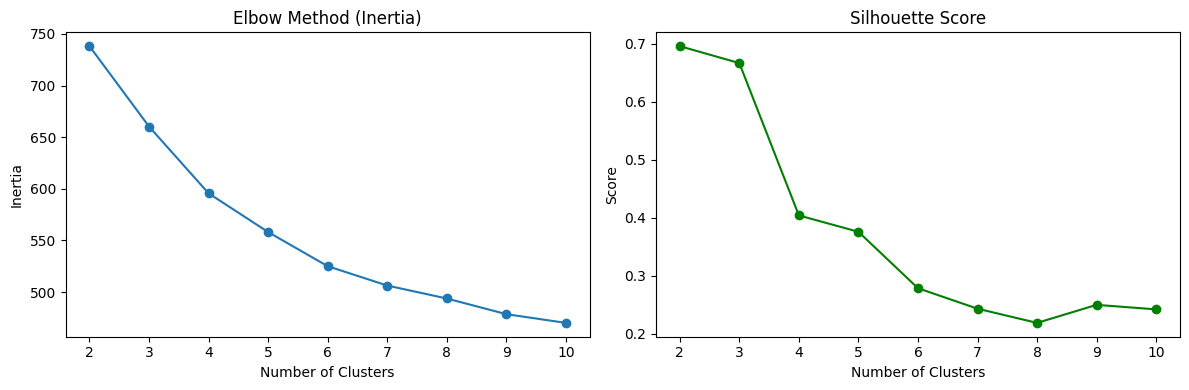

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(k_range, inertias, marker="o")
ax[0].set_title("Elbow Method (Inertia)")
ax[0].set_xlabel("Number of Clusters")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_range, silhouette_scores, marker="o", color="green")
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("Number of Clusters")
ax[1].set_ylabel("Score")

plt.tight_layout()


In [12]:
from sktime.clustering.k_means import TimeSeriesKMeans
from sklearn.metrics import silhouette_score
from sktime.utils.plotting import plot_series


# Try a range of k values to find the best number of clusters
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = TimeSeriesKMeans(n_clusters=k, random_state=42, metric="dtw")
    labels = kmeans.fit_predict(X_paa)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_paa, labels))


/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: Runtim

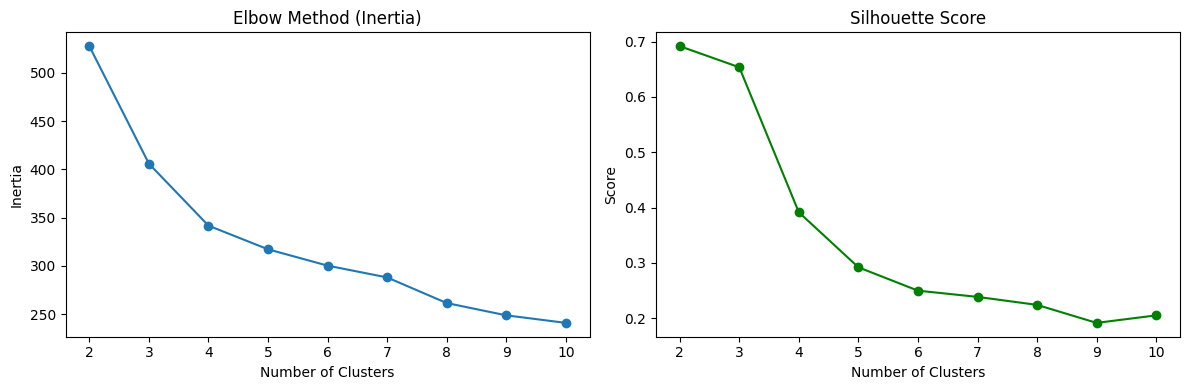

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(k_range, inertias, marker="o")
ax[0].set_title("Elbow Method (Inertia)")
ax[0].set_xlabel("Number of Clusters")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_range, silhouette_scores, marker="o", color="green")
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("Number of Clusters")
ax[1].set_ylabel("Score")

plt.tight_layout()

In [15]:
X_paa.shape

(1134, 10)

In [ ]:
import matplotlib.pyplot as plt
from sktime.clustering.k_means import TimeSeriesKMeans

# Assuming X_paa is 2D: shape (n_series, n_segments)
# If it's 3D (n_series, n_segments, 1), squeeze it:
# X_paa = X_paa.squeeze(-1)

# KMeans with Euclidean
kmeans_eucl = TimeSeriesKMeans(n_clusters=4, metric="euclidean", random_state=42)
labels_eucl = kmeans_eucl.fit_predict(X_paa)
centroids_eucl = kmeans_eucl.cluster_centers_

# KMeans with DTW
kmeans_dtw = TimeSeriesKMeans(n_clusters=4, metric="dtw", random_state=42)
labels_dtw = kmeans_dtw.fit_predict(X_paa)
centroids_dtw = kmeans_dtw.cluster_centers_


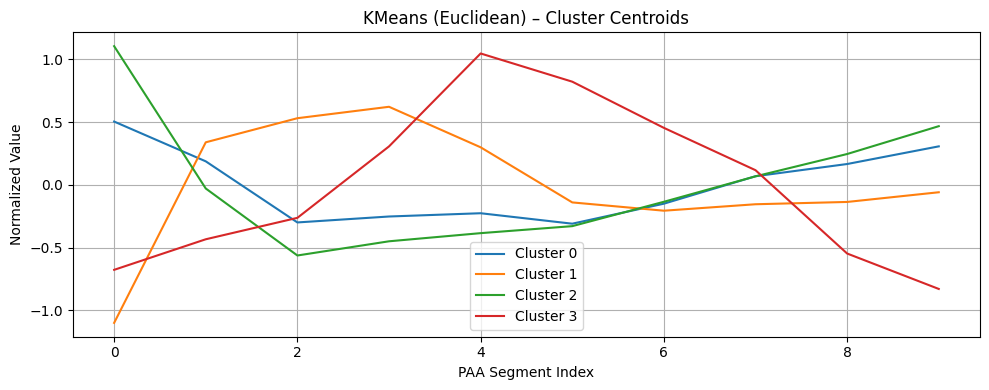

In [17]:
# Ensure centroids are 2D arrays: (n_clusters, n_timepoints)
centroids_eucl_2d = np.array([c.ravel() for c in centroids_eucl])

plt.figure(figsize=(10, 4))
for i in range(4):
    plt.plot(centroids_eucl_2d[i], label=f"Cluster {i}")
plt.title("KMeans (Euclidean) – Cluster Centroids")
plt.xlabel("PAA Segment Index")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


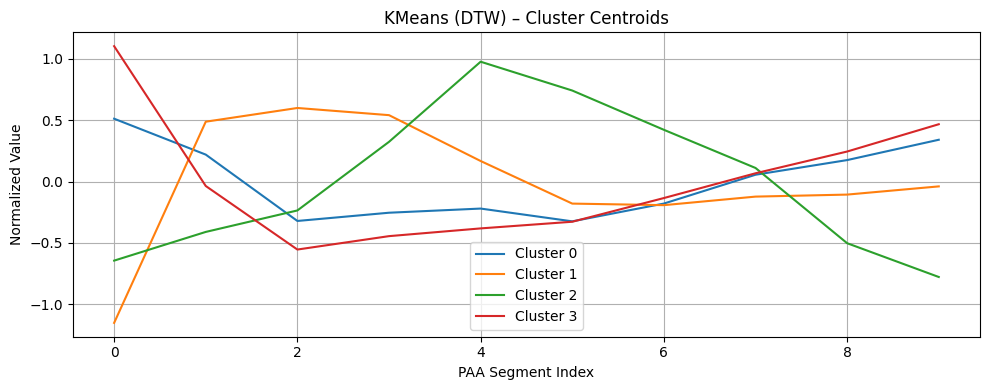

In [18]:
centroids_dtw_2d = np.array([c.ravel() for c in centroids_dtw])

plt.figure(figsize=(10, 4))
for i in range(4):
    plt.plot(centroids_dtw_2d[i], label=f"Cluster {i}")
plt.title("KMeans (DTW) – Cluster Centroids")
plt.xlabel("PAA Segment Index")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Combine original genre & rating with cluster assignments
df_clusters = df[["genre", "rating"]].copy()
df_clusters["cluster_dtw"] = labels_dtw
df_clusters["cluster_eucl"] = labels_eucl


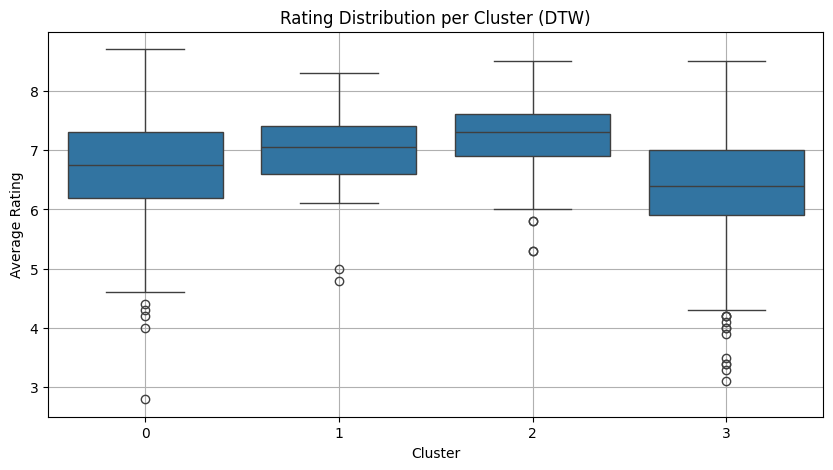

In [22]:
# Rating distribution per cluster (DTW)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clusters, x="cluster_dtw", y="rating")
plt.title("Rating Distribution per Cluster (DTW)")
plt.xlabel("Cluster")
plt.ylabel("Average Rating")
plt.grid(True)
plt.show()


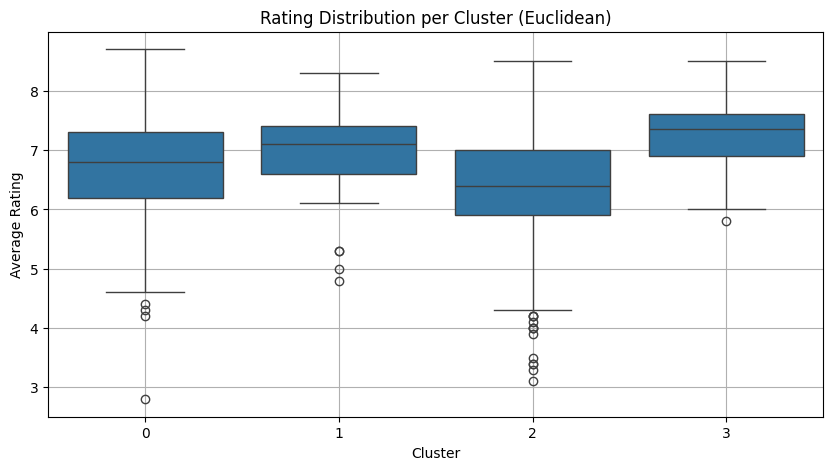

In [23]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clusters, x="cluster_eucl", y="rating")
plt.title("Rating Distribution per Cluster (Euclidean)")
plt.xlabel("Cluster")
plt.ylabel("Average Rating")
plt.grid(True)
plt.show()


In [24]:
df_clusters_exploded = df_clusters.explode("genre").reset_index(drop=True)


In [ ]:
# Flatten genres: ensure each movie has multiple rows, one per genre
df_genre_split = df.copy()
df_genre_split["genre"] = df_genre_split["genre"].apply(
    lambda x: x if isinstance(x, list) else [x]
)
df_genre_split = df_genre_split.explode("genre").reset_index(drop=True)

# Merge cluster labels
df_genre_split["cluster_dtw"] = labels_dtw
df_genre_split["cluster_eucl"] = labels_eucl


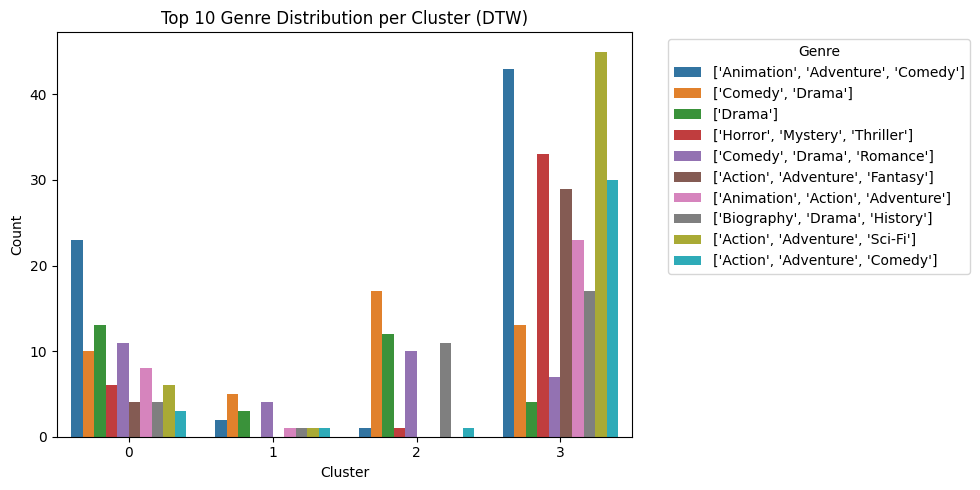

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute top N genres
top_genres = df_genre_split["genre"].value_counts().nlargest(10).index
df_top = df_genre_split[df_genre_split["genre"].isin(top_genres)]

# Plot DTW clusters
plt.figure(figsize=(10, 5))
sns.countplot(data=df_top, x="cluster_dtw", hue="genre")
plt.title("Top 10 Genre Distribution per Cluster (DTW)")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


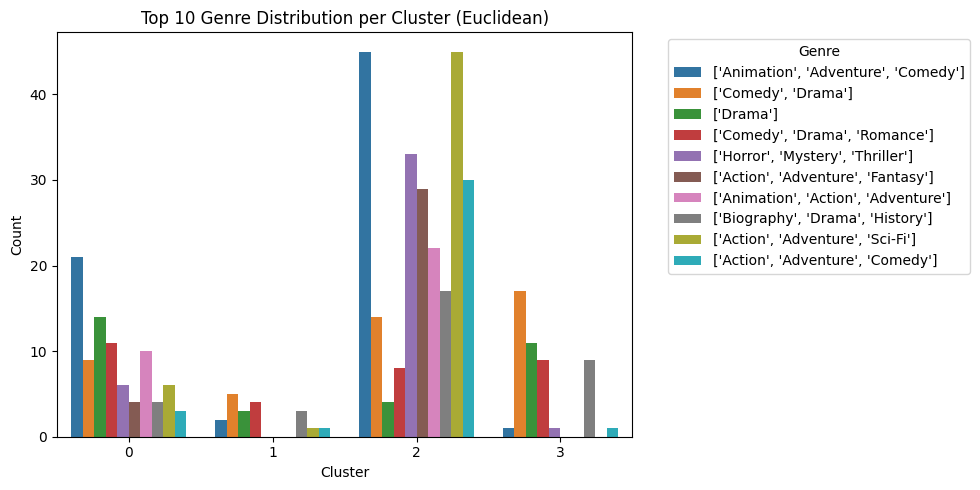

In [31]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_top, x="cluster_eucl", hue="genre")
plt.title("Top 10 Genre Distribution per Cluster (Euclidean)")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [29]:
# Count how many time series are in each cluster
dtw_counts = pd.Series(labels_dtw).value_counts().sort_index()
print("DTW – Time Series per Cluster:")
print(dtw_counts)


DTW – Time Series per Cluster:
0    212
1     58
2    151
3    713
Name: count, dtype: int64


In [30]:
eucl_counts = pd.Series(labels_eucl).value_counts().sort_index()
print("Euclidean – Time Series per Cluster:")
print(eucl_counts)


Euclidean – Time Series per Cluster:
0    223
1     68
2    709
3    134
Name: count, dtype: int64


/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/daviderizzello/Documents/Uni/D

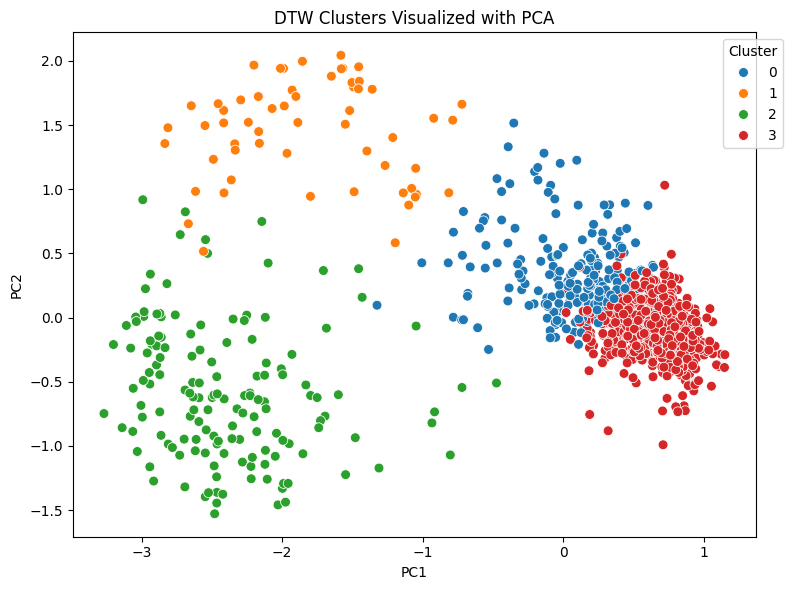

In [32]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: flatten to 2D if it's (n, m, 1)
X_flat = X_paa.squeeze() if X_paa.ndim == 3 else X_paa

# ----------------- PCA ------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_flat)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_dtw, palette="tab10", s=50)
plt.title("DTW Clusters Visualized with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/daviderizzello/Documents/Uni/DM2/Progetto/

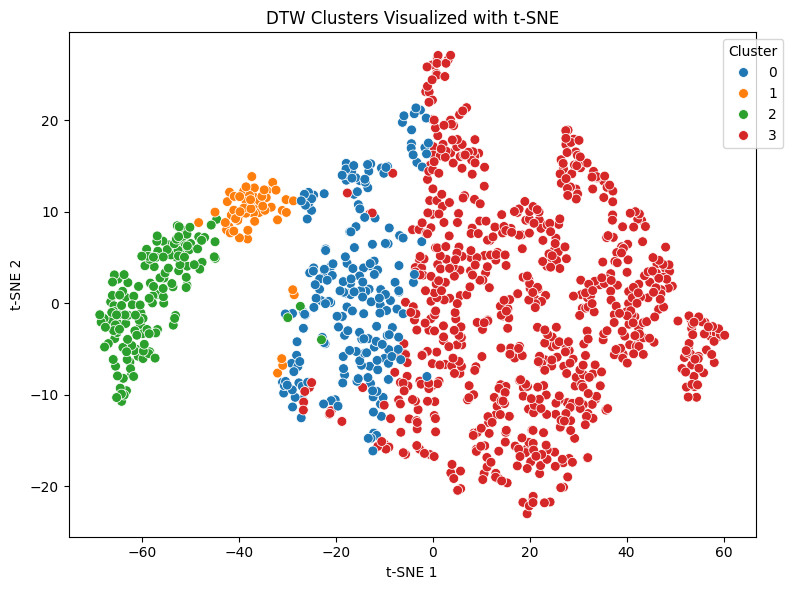

In [33]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_flat)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels_dtw, palette="tab10", s=50)
plt.title("DTW Clusters Visualized with t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

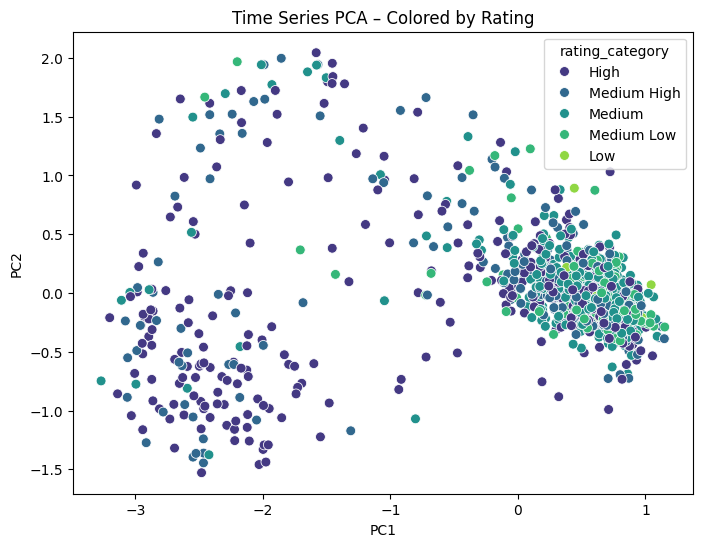

In [37]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], hue=df["rating_category"], palette="viridis", s=50
)
plt.title("Time Series PCA – Colored by Rating")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Average Rating")
plt.tight_layout()
plt.show()


RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

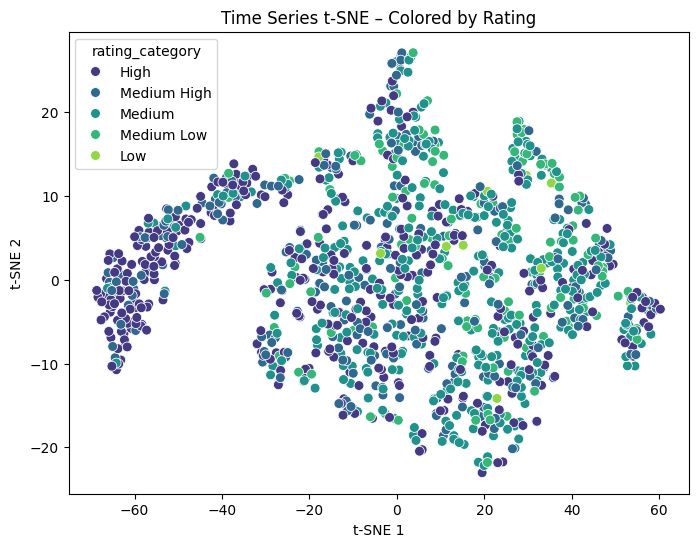

In [38]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df["rating_category"], palette="viridis", s=50
)
plt.title("Time Series t-SNE – Colored by Rating")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(label="Average Rating")
plt.tight_layout()
plt.show()


In [ ]:
X_paa_flat = X_paa.squeeze() if X_paa.ndim == 3 else X_paa

# Convert to DataFrame and give it column names
X_paa_df = pd.DataFrame(
    X_paa_flat, columns=[f"paa_{i}" for i in range(X_paa_flat.shape[1])]
)
df_merged = pd.concat(
    [df.reset_index(drop=True), X_paa_df.reset_index(drop=True)], axis=1
)


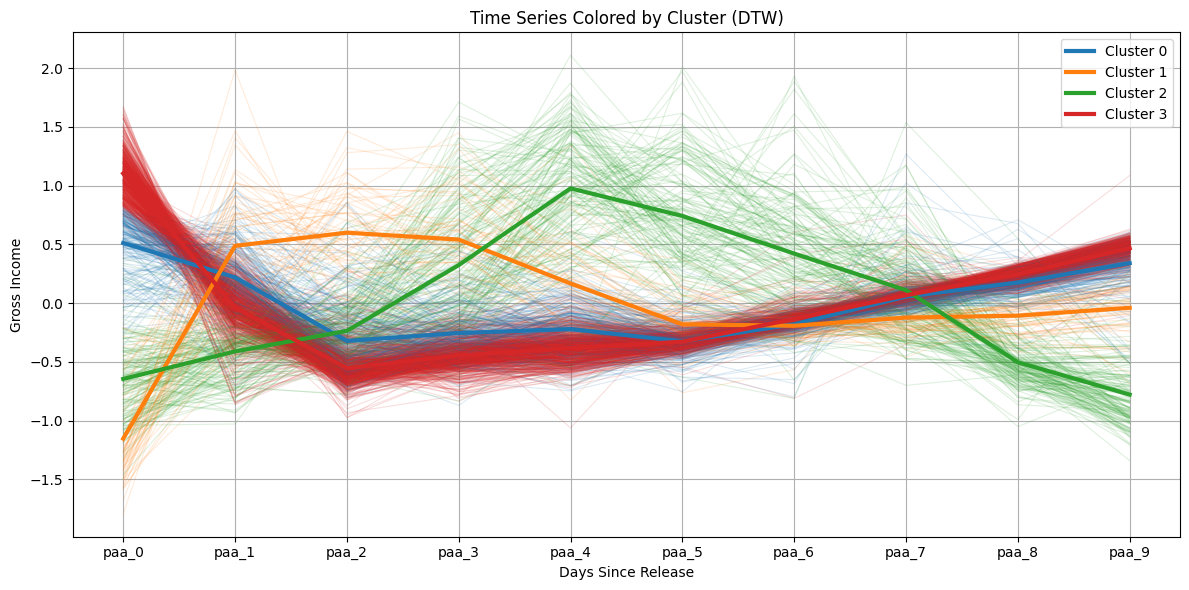

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Choose a color palette with 4 distinct colors (k = 4)
palette = sns.color_palette("tab10", n_colors=4)

plt.figure(figsize=(12, 6))

for i in range(X_paa_df.shape[0]):
    cluster_id = labels_dtw[i]
    plt.plot(X_paa_df.iloc[i], alpha=0.15, color=palette[cluster_id], linewidth=0.8)

# Optional: plot cluster means on top
for cluster_id in np.unique(labels_dtw):
    cluster_series = X_paa_df[labels_dtw == cluster_id]
    cluster_mean = cluster_series.mean(axis=0)
    plt.plot(
        cluster_mean,
        color=palette[cluster_id],
        linewidth=3,
        label=f"Cluster {cluster_id}",
    )

plt.title("Time Series Colored by Cluster (DTW)")
plt.xlabel("Days Since Release")
plt.ylabel("Gross Income")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [51]:
centroids = X_paa_df.groupby(labels_dtw).mean().to_numpy()


In [ ]:
from sktime.distances import distance

closest_ts_indices = []

# Per ogni centroide
for cluster_id, centroid in enumerate(centroids):
    min_dist = float("inf")
    best_idx = None

    for i, ts in enumerate(X_paa_df.to_numpy()):
        if labels_dtw[i] == cluster_id:
            dist = distance(ts, centroid, metric="dtw")
            if dist < min_dist:
                min_dist = dist
                best_idx = i

    closest_ts_indices.append(best_idx)

print("Indice della TS più vicina per ciascun cluster:", closest_ts_indices)


Indice della TS più vicina per ciascun cluster: [1067, 1054, 794, 950]
